In [1]:
%load_ext autoreload
%autoreload 2

# `import`

In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from dice_rl_TU_Vienna.latex import latex_labels
from dice_rl_TU_Vienna.plot.general import plot_histogram
from dice_rl_TU_Vienna.plot.tabular import plot

from dice_rl_TU_Vienna.estimators.get import get_pv_s, get_gammas_log10
from dice_rl_TU_Vienna.estimators.tabular.test import test_auxiliary_estimates
from dice_rl_TU_Vienna.estimators.onpolicy import OnPE
from dice_rl_TU_Vienna.estimators.tabular.importance_sampling   import IS
from dice_rl_TU_Vienna.estimators.tabular.tabular_vafe          import TabularVafe
from dice_rl_TU_Vienna.estimators.tabular.tabular_dice          import TabularDice
from dice_rl_TU_Vienna.estimators.tabular.tabular_dual_dice     import TabularDualDice
from dice_rl_TU_Vienna.estimators.tabular.tabular_gradient_dice import TabularGradientDice
from dice_rl_TU_Vienna.estimators.tabular.tabular_OffPE         import AuxiliaryEstimates

from dice_rl_TU_Vienna.utils.seeds import set_all_seeds
from dice_rl_TU_Vienna.utils.bedtime import computer_sleep
from dice_rl_TU_Vienna.utils.general import iterate_print

/Users/richardweiss/Documents/.venvs/dice_rl_TU_Vienna/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [3]:
pd.set_option('display.max_rows', None)

# Prepare

In [4]:
dir_data   = os.path.join("data",   "RRT")
dir_images = os.path.join("images", "RRT")

In [5]:
kinds = ["behavior", "evaluation"]

In [6]:
dir_evaluation = {
    kind: os.path.join(dir_data, kind)
        for kind in kinds
}

In [7]:
split = pd.read_parquet( os.path.join(dir_data, "split.parquet") )

In [8]:
split.head()

,bloc,icustayid,state,action,outcome,reward,ai_action,concordant,p0_model,p1_model,probabilities_model,p0_phys,p1_phys,probabilities_phys
0,1,62867,115,0,0,0,0,1,0.99,0.01,"[0.99, 0.010000000000000009]",0.990000,0.010000,"[0.99, 0.010000000000000009]"
1,2,62867,368,0,0,0,0,1,0.99,0.01,"[0.99, 0.010000000000000009]",0.809503,0.190497,"[0.8095027624309392, 0.19049723756906078]"
2,3,62867,373,0,0,0,0,1,0.99,0.01,"[0.99, 0.010000000000000009]",0.990000,0.010000,"[0.99, 0.010000000000000009]"
3,4,62867,360,0,0,0,1,0,0.01,0.99,"[0.01, 0.99]",0.720000,0.280000,"[0.72, 0.28]"
4,5,62867,368,0,0,0,0,1,0.99,0.01,"[0.99, 0.010000000000000009]",0.809503,0.190497,"[0.8095027624309392, 0.19049723756906078]"


In [9]:
n_obs = split["state"] .max() + 1
n_act = split["action"].max() + 1

n_obs, n_act

(502, 2)

In [10]:
absorbing_states = [500, 501]

for i in range( len(split) ):
    if split.at[i, "state"] in absorbing_states:
        # split.at[i, "probabilities_model"] = np.ones(n_act) / n_act
        split.at[i, "probabilities_phys"]  = np.ones(n_act) / n_act

In [11]:
split.head(50)

,bloc,icustayid,state,action,outcome,reward,ai_action,concordant,p0_model,p1_model,probabilities_model,p0_phys,p1_phys,probabilities_phys
0,1,62867,115,0,0,0,0,1,0.99,0.01,"[0.99, 0.010000000000000009]",0.990000,0.010000,"[0.99, 0.010000000000000009]"
1,2,62867,368,0,0,0,0,1,0.99,0.01,"[0.99, 0.010000000000000009]",0.809503,0.190497,"[0.8095027624309392, 0.19049723756906078]"
2,3,62867,373,0,0,0,0,1,0.99,0.01,"[0.99, 0.010000000000000009]",0.990000,0.010000,"[0.99, 0.010000000000000009]"
3,4,62867,360,0,0,0,1,0,0.01,0.99,"[0.01, 0.99]",0.720000,0.280000,"[0.72, 0.28]"
4,5,62867,368,0,0,0,0,1,0.99,0.01,"[0.99, 0.010000000000000009]",0.809503,0.190497,"[0.8095027624309392, 0.19049723756906078]"
5,6,62867,373,0,0,0,0,1,0.99,0.01,"[0.99, 0.010000000000000009]",0.990000,0.010000,"[0.99, 0.010000000000000009]"
6,7,62867,360,0,0,0,1,0,0.01,0.99,"[0.01, 0.99]",0.720000,0.280000,"[0.72, 0.28]"
7,8,62867,360,0,0,0,1,0,0.01,0.99,"[0.01, 0.99]",0.720000,0.280000,"[0.72, 0.28]"
8,9,62867,360,0,0,0,1,0,0.01,0.99,"[0.01, 0.99]",0.720000,0.280000,"[0.72, 0.28]"
9,10,62867,373,0,0,0,0,1,0.99,0.01,"[0.99, 0.010000000000000009]",0.990000,0.010000,"[0.99, 0.010000000000000009]"


In [12]:
def get_dataset(split, padding=False, seed=None, overwrite=False):
    set_all_seeds(seed)

    path = os.path.join(dir_data, "dataset.parquet")
    if os.path.exists(path) and not overwrite: return pd.read_parquet(path)

    dataset = {
        "id": [],
        "t": [],
        "obs_init": [],
        "obs": [],
        "act": [],
        "rew": [],
        "obs_next": [],
        "probs_init": [],
        "probs_init_behavior": [],
        "probs": [],
        "probs_behavior": [],
        "probs_next": [],
        "probs_next_behavior": [],
    }

    for i in range(len(split)):
        id = split.loc[i, "icustayid"]
        t  = split.loc[i, "bloc"] - 1 # type: ignore

        if i == 0 or split.loc[i-1, "icustayid"] != id:
            obs_init            = split.loc[i, "state"]
            probs_init          = split.loc[i, "probabilities_model"]
            probs_init_behavior = split.loc[i, "probabilities_phys"]

        if i == len(split) - 1 or split.loc[i+1, "icustayid"] != id:
            if not padding: continue

            obs = split.loc[i, "state"]
            act = np.random.choice( range(n_act), p=split.loc[i, "probabilities_phys"], )
            rew = 0
            obs_next = obs

            probs          = split.loc[i, "probabilities_model"]
            probs_behavior = split.loc[i, "probabilities_phys"]
            probs_next = probs
            probs_next_behavior = probs_behavior

        else:
            obs      = split.loc[i, "state"]
            act      = split.loc[i, "action"]
            rew      = split.loc[i+1, "reward"]
            obs_next = split.loc[i+1, "state"]

            probs               = split.loc[i, "probabilities_model"]
            probs_behavior      = split.loc[i, "probabilities_phys"]
            probs_next          = split.loc[i+1, "probabilities_model"]
            probs_next_behavior = split.loc[i+1, "probabilities_phys"]

        dataset["id"].append(id)
        dataset["t"] .append(t)

        dataset["obs_init"].append(obs_init)
        dataset["obs"]     .append(obs)
        dataset["act"]     .append(act)
        dataset["rew"]     .append(rew)
        dataset["obs_next"].append(obs_next)

        dataset["probs_init"]         .append(probs_init)
        dataset["probs_init_behavior"].append(probs_init_behavior)
        dataset["probs"]              .append(probs)
        dataset["probs_behavior"]     .append(probs_behavior)
        dataset["probs_next"]         .append(probs_next)
        dataset["probs_next_behavior"].append(probs_next_behavior)

    dataset = pd.DataFrame(dataset)
    dataset.to_parquet(path)

    return dataset

In [13]:
def dataset_evluation_to_behavior(df):
    column_names = [
        "id", "t",
        "obs_init", "obs", "act", "rew", "obs_next",
        "probs_init_behavior", "probs_behavior", "probs_next_behavior",
    ]
    rename_columns = {
        "probs_init_behavior": "probs_init",
        "probs_behavior": "probs",
        "probs_next_behavior": "probs_next",
    }

    return df[column_names].rename(columns=rename_columns)

In [14]:
dataset = {}

x = get_dataset(split, padding=True, seed=0, overwrite=True)
y = dataset_evluation_to_behavior(x)

dataset["evaluation"] = x
dataset["behavior"]   = y

In [15]:
dataset["evaluation"].head(20)

,id,t,obs_init,obs,act,rew,obs_next,probs_init,probs_init_behavior,probs,probs_behavior,probs_next,probs_next_behavior
0,62867,0,115,115,0,0,368,"[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]","[0.8095027624309392, 0.19049723756906078]"
1,62867,1,115,368,0,0,373,"[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]","[0.8095027624309392, 0.19049723756906078]","[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]"
2,62867,2,115,373,0,0,360,"[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]","[0.01, 0.99]","[0.72, 0.28]"
3,62867,3,115,360,0,0,368,"[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]","[0.01, 0.99]","[0.72, 0.28]","[0.99, 0.010000000000000009]","[0.8095027624309392, 0.19049723756906078]"
4,62867,4,115,368,0,0,373,"[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]","[0.8095027624309392, 0.19049723756906078]","[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]"
5,62867,5,115,373,0,0,360,"[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]","[0.01, 0.99]","[0.72, 0.28]"
6,62867,6,115,360,0,0,360,"[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]","[0.01, 0.99]","[0.72, 0.28]","[0.01, 0.99]","[0.72, 0.28]"
7,62867,7,115,360,0,0,360,"[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]","[0.01, 0.99]","[0.72, 0.28]","[0.01, 0.99]","[0.72, 0.28]"
8,62867,8,115,360,0,0,373,"[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]","[0.01, 0.99]","[0.72, 0.28]","[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]"
9,62867,9,115,373,0,0,360,"[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]","[0.99, 0.010000000000000009]","[0.01, 0.99]","[0.72, 0.28]"


In [36]:
auxiliary_estimates = {
    kind: AuxiliaryEstimates(
        dataset[kind],
        n_obs, n_act,
        dir_evaluation[kind],
        verbosity=1,
    )
        for kind in iterate_print(kinds, "kind")
}

kind=behavior
trying to load auxiliary estimates from data/RRT/behavior
loaded data/RRT/behavior/d0_bar.npy
loaded data/RRT/behavior/dD_bar.npy
loaded data/RRT/behavior/P_bar.npy
loaded data/RRT/behavior/r_bar.npy
loaded data/RRT/behavior/n.npy
kind=evaluation
trying to load auxiliary estimates from data/RRT/evaluation
loaded data/RRT/evaluation/d0_bar.npy
loaded data/RRT/evaluation/dD_bar.npy
loaded data/RRT/evaluation/P_bar.npy
loaded data/RRT/evaluation/r_bar.npy
loaded data/RRT/evaluation/n.npy


In [37]:
estimators = { kind: {} for kind in kinds }

print("OnPE")
kind = "behavior"
print(f"{kind=}")
label = "OnPE"
estimators[kind][label] = OnPE(dataset[kind])

print("IS")
kind = "evaluation"
print(f"{kind=}")
label = "IS"
estimators[kind][label] = IS(dataset[kind])

print("DICE")
for kind in iterate_print(kinds, "kind"):
    for estimator_type in [
        TabularVafe, TabularDice, TabularDualDice, TabularGradientDice, ]:

        estimator = estimator_type(
            dataset[kind],
            n_obs,
            n_act,
            dir_evaluation[kind],
            verbosity=1,
            auxiliary_estimates=auxiliary_estimates[kind],
        )

        estimators[kind][estimator.__name__] = estimator

OnPE
kind='behavior'
IS
kind='evaluation'
DICE
kind=behavior
kind=evaluation


In [38]:
estimators

{'behavior': {'OnPE': <dice_rl_TU_Vienna.estimators.onpolicy.OnPE at 0x31f8a9f50>,
  'TabularVafe': <dice_rl_TU_Vienna.estimators.tabular.tabular_vafe.TabularVafe at 0x31f722110>,
  'TabularDice': <dice_rl_TU_Vienna.estimators.tabular.tabular_dice.TabularDice at 0x31dbb1fd0>,
  'TabularDualDice': <dice_rl_TU_Vienna.estimators.tabular.tabular_dual_dice.TabularDualDice at 0x31f360110>,
  'TabularGradientDice': <dice_rl_TU_Vienna.estimators.tabular.tabular_gradient_dice.TabularGradientDice at 0x31f8cc790>},
 'evaluation': {'IS': <dice_rl_TU_Vienna.estimators.tabular.importance_sampling.IS at 0x3229e1990>,
  'TabularVafe': <dice_rl_TU_Vienna.estimators.tabular.tabular_vafe.TabularVafe at 0x31f879050>,
  'TabularDice': <dice_rl_TU_Vienna.estimators.tabular.tabular_dice.TabularDice at 0x30f5a0710>,
  'TabularDualDice': <dice_rl_TU_Vienna.estimators.tabular.tabular_dual_dice.TabularDualDice at 0x32294c710>,
  'TabularGradientDice': <dice_rl_TU_Vienna.estimators.tabular.tabular_gradient_dice.T

# `get_pvs`

In [39]:
gammas = get_gammas_log10()

projected = True
modified = True
lamda = 1e-6

## Discounted

In [40]:
pvs = { kind: {} for kind in kinds }

In [41]:
kind = "behavior"
label = "OnPE"

pvs[kind][label] = get_pv_s(
    estimator_s=estimators[kind]["OnPE"],
    gamma_s=gammas,
)

In [42]:
kind = "evaluation"
label = "IS"

pvs[kind][label] = {}

for weighted in [False, True]:
    print(f"{weighted=}")
    pvs[kind][label][weighted] = get_pv_s(
        estimator_s=estimators[kind][label],
        gamma_s=gammas,
        weighted=weighted,
    )

weighted=False
weighted=True


In [43]:
for kind in iterate_print(kinds, "kind"):
    dir = dir_evaluation[kind]

    label = "TabularVafe"
    print(label)
    file = os.path.join(dir, f"pvs_{label}.npy")

    if os.path.exists(file):
        arr = np.load(file)
    else:
        arr = get_pv_s(
            estimator_s=estimators[kind][label],
            gamma_s=gammas,
            projected=projected, weighted=None,
            modified=modified, lamda=lamda,
            verbosity=2,
        )
        np.save(file, arr)

    pvs[kind][label] = arr

    for label in [
        "TabularDice", "TabularDualDice", "TabularGradientDice"]:

        print(label)
        pvs[kind][label] = {}

        for weighted, postfix in zip([False, True], ["simple", "weighted"]):
            print(f"{weighted=}")

            file = os.path.join(dir, f"pvs_{label}_{postfix}.npy")

            if os.path.exists(file):
                arr = np.load(file)
            else:
                arr = get_pv_s(
                    estimators[kind][label],
                    gammas,
                    projected=projected, weighted=weighted,
                    modified=modified, lamda=lamda,
                    verbosity=2,
                )
                np.save(file, arr)

            pvs[kind][label][weighted] = arr

kind=behavior
TabularVafe
TabularDice
weighted=False
weighted=True
TabularDualDice
weighted=False
weighted=True
TabularGradientDice
weighted=False
weighted=True
kind=evaluation
TabularVafe
TabularDice
weighted=False
weighted=True
TabularDualDice
weighted=False
weighted=True
TabularGradientDice
weighted=False
weighted=True


In [44]:
pvs

{'behavior': {'OnPE': array([4.08687279e+00, 3.02157979e+00, 2.03015408e+00, 1.27258065e+00,
         7.62804989e-01, 4.45034337e-01, 2.55565760e-01, 1.45433361e-01,
         8.23339230e-02, 4.64752567e-02, 2.61906905e-02, 1.47457746e-02,
         8.29775277e-03, 4.66793973e-03, 2.62553552e-03, 1.47662428e-03,
         8.30422889e-04]),
  'TabularVafe': array([4.00387742e+00, 2.88511573e+00, 1.91479990e+00, 1.19534624e+00,
         7.15979568e-01, 4.17820590e-01, 2.40031310e-01, 1.36634816e-01,
         7.73682479e-02, 4.36775698e-02, 2.46158338e-02, 1.38596734e-02,
         7.79930743e-03, 4.38759501e-03, 2.46787089e-03, 1.38795815e-03,
         7.80560745e-04]),
  'TabularDice': {False: array([4.00387742e+00, 2.88511573e+00, 1.91479990e+00, 1.19534624e+00,
          7.15979568e-01, 4.17820590e-01, 2.40031310e-01, 1.36634816e-01,
          7.73682479e-02, 4.36775698e-02, 2.46158338e-02, 1.38596734e-02,
          7.79930743e-03, 4.38759501e-03, 2.46787089e-03, 1.38795815e-03,
         

## Undiscounted

In [45]:
pv = { kind: {} for kind in kinds }

In [46]:
kind = "behavior"
label = "OnPE"

pv[kind][label] = get_pv_s(
    estimator_s=estimators[kind]["OnPE"],
    gamma_s=1.0,
    scale=False,
)

In [47]:
kind = "evaluation"
label = "IS"

pv[kind][label] = {}

for weighted in [False, True]:
    print(f"{weighted=}")
    pv[kind][label][weighted] = get_pv_s(
        estimator_s=estimators[kind][label],
        gamma_s=1.0,
        weighted=weighted,
        scale=False,
    )

weighted=False
weighted=True


In [48]:
pv

{'behavior': {'OnPE': 83.04948908034461},
 'evaluation': {'IS': {False: 86.74868337617848, True: 85.82008591236298}}}

# Plot

## Policy Values

In [49]:
def plot_pvs_RRT(kind, weighted):

    plot_infos = []

    plot_infos += [
        {
            "x": 0.99,
            "label": "gamma=0.99",
            "color": "black",
            "marker": None,
        }
    ]

    if kind == "behavior":
        plot_infos += [
            {
                "y": pv[kind]["OnPE"],
                "label": None,
                "color": "lightgrey",
                "marker": "v",
            },
        ]
    if kind == "evaluation":
        plot_infos += [
            {
                "y": pv[kind]["IS"][weighted],
                "label": None,
                "color": "pink" if not weighted else "deeppink",
                "marker": "+" if not weighted else "x",
            },
        ]

    if kind == "behavior":
        plot_infos += [
            {
                "x": gammas,
                "y": pvs[kind]["OnPE"],
                "label": "OnPE",
                "color": "lightgrey",
                "marker": "v",
            },
        ]
    plot_infos += [
        {
            "x": gammas,
            "y": pvs[kind]["TabularVafe"],
            "label": "TabularVafe",
            "color": "blue",
            "marker": "1",
        },
        {
            "x": gammas,
            "y": pvs[kind]["TabularDice"][weighted],
            "label": "TabularDice",
            "color": "orange",
            "marker": "2",
        },
        {
            "x": gammas,
            "y": pvs[kind]["TabularDualDice"][weighted],
            "label": "TabularDualDice",
            "color": "green",
            "marker": "3",
        },
        {
            "x": gammas,
            "y": pvs[kind]["TabularGradientDice"][weighted],
            "label": f"TabularGradientDice, lamda={lamda}",
            "color": "red",
            "marker": "4",
        },
    ]
    if kind == "evaluation":
        plot_infos += [
            {
                "x": gammas,
                "y": pvs[kind]["IS"][weighted],
                "label": "SIS" if not weighted else "WIS",
                "color": "pink" if not weighted else "deeppink",
                "marker": "+" if not weighted else "x",
            },
        ]

    suptitle = f"RRT - {kind} - PVs" + "\n" + f"{projected=}, {weighted=}"

    one_minus_gamma = True
    scale_pv = True

    xlabel = None
    ylabel = latex_labels["pv_scaled"]()

    xlim = None
    ylim = (30, 90)

    scale_x = True
    scale_y = False

    legend = { "loc": "lower right", }
    dir = dir_images

    plot(
        plot_infos,
        suptitle,
        one_minus_gamma, scale_pv,
        xlabel, ylabel,
        xlim, ylim,
        scale_x, scale_y,
        legend, # type: ignore
        dir,
    )

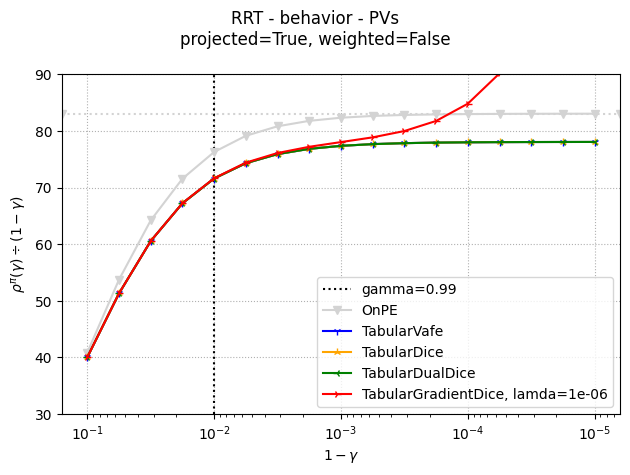

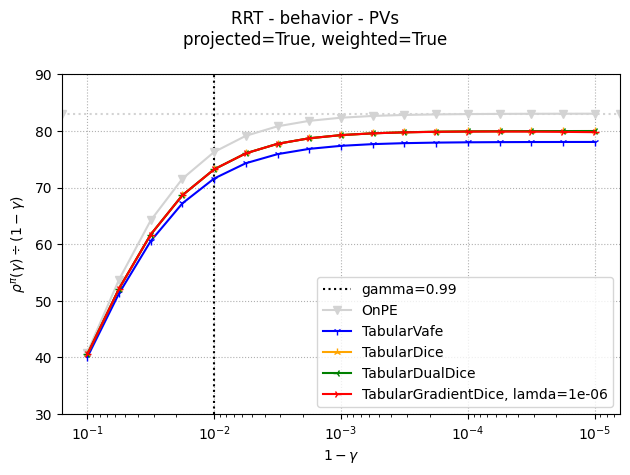

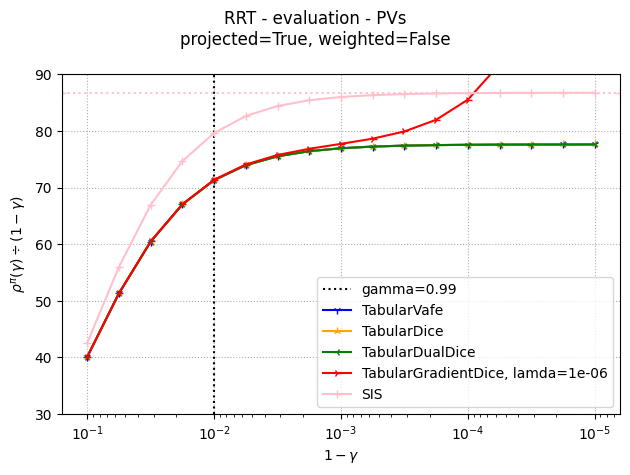

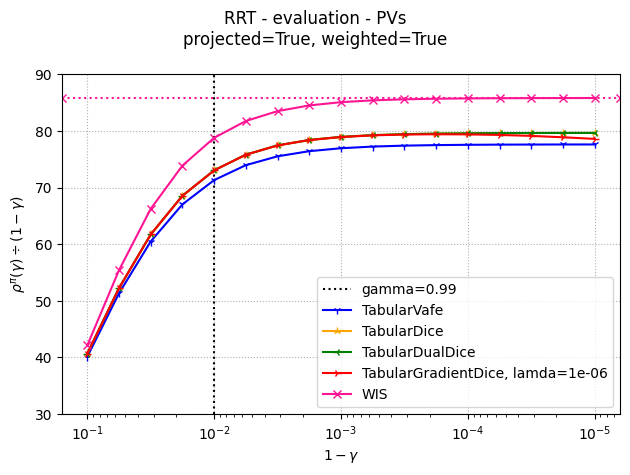

In [50]:
for kind in kinds:
    for weighted in [False, True]:
        plot_pvs_RRT(kind, weighted)

# Supplementary

## Policy Ratios

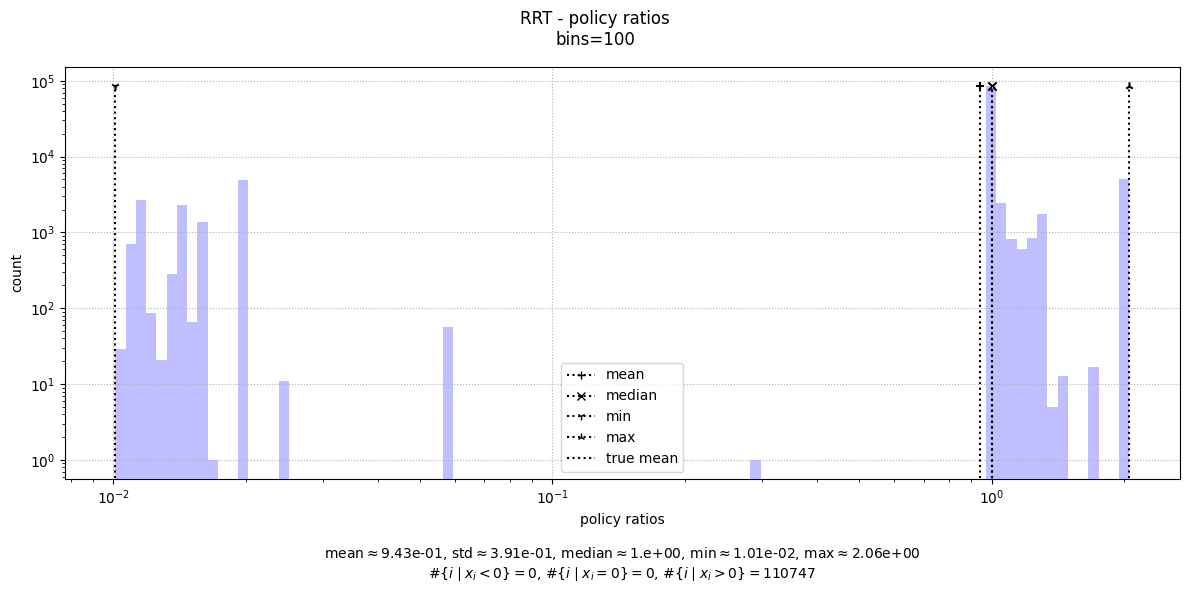

In [31]:
plot_histogram(
    data=estimators["evaluation"]["IS"].q, bins=100, moving_average_radius=None,
    suptitle=f"RRT - policy ratios", xlabel="policy ratios",
    xscale=True, yscale=True,
    true_mean=1,
    dir=dir_images,
)

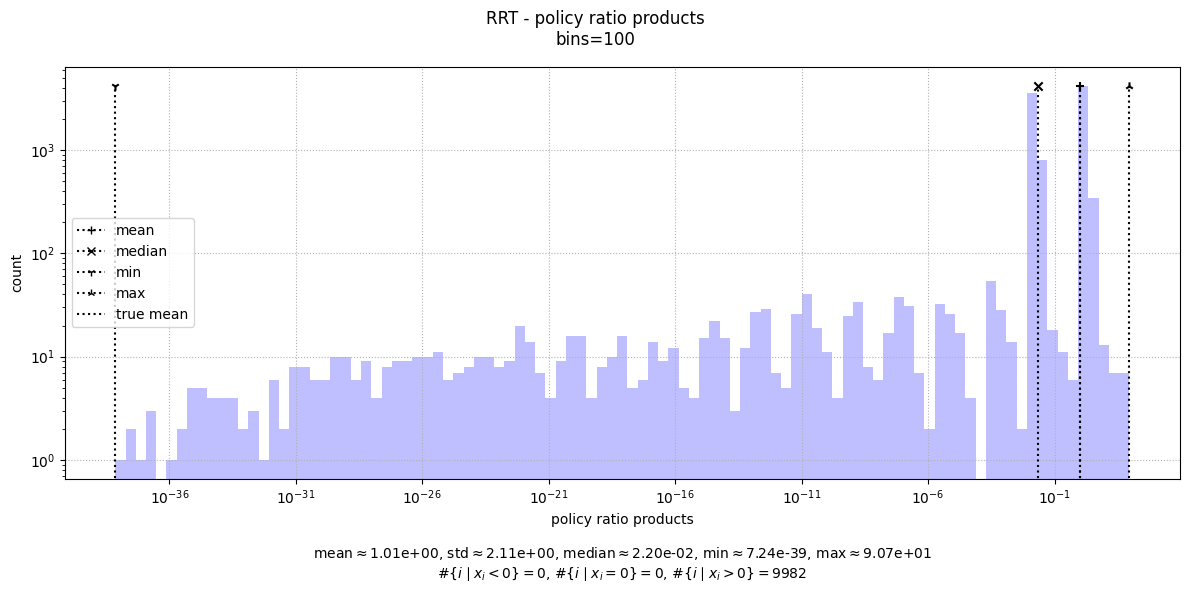

In [32]:
plot_histogram(
    data=estimators["evaluation"]["IS"].W, bins=100,
    suptitle=f"RRT - policy ratio products", xlabel="policy ratio products",
    xscale=True, yscale=True,
    true_mean=1,
    dir=dir_images,
)

## `AuxiliaryEstimates`

In [33]:
def test_auxiliary_estimates_RRT(kind):
    test_auxiliary_estimates(
        auxiliary_estimates=auxiliary_estimates[kind],
        title_prefix=f"RRT - {kind}",
        dir=os.path.join(dir_images, "auxiliary_estimates"),
        epsilon=1e-3,
    )

# (s, a) visited:
{'absolute': 567, 'relative': 0.5647410358565738}
# (s, a) not visited:
{'absolute': 437, 'relative': 0.4352589641434263}

#{i: dD_bar[i] == 0, P_bar[i, :] != 0} = 0
#{i: dD_bar[i] == 0, P_bar[:, i] != 0} = 4576
#{i: dD_bar[i] == 0, d0_bar[i] != 0} = 154

# ---------------------------------------------------------------- # 



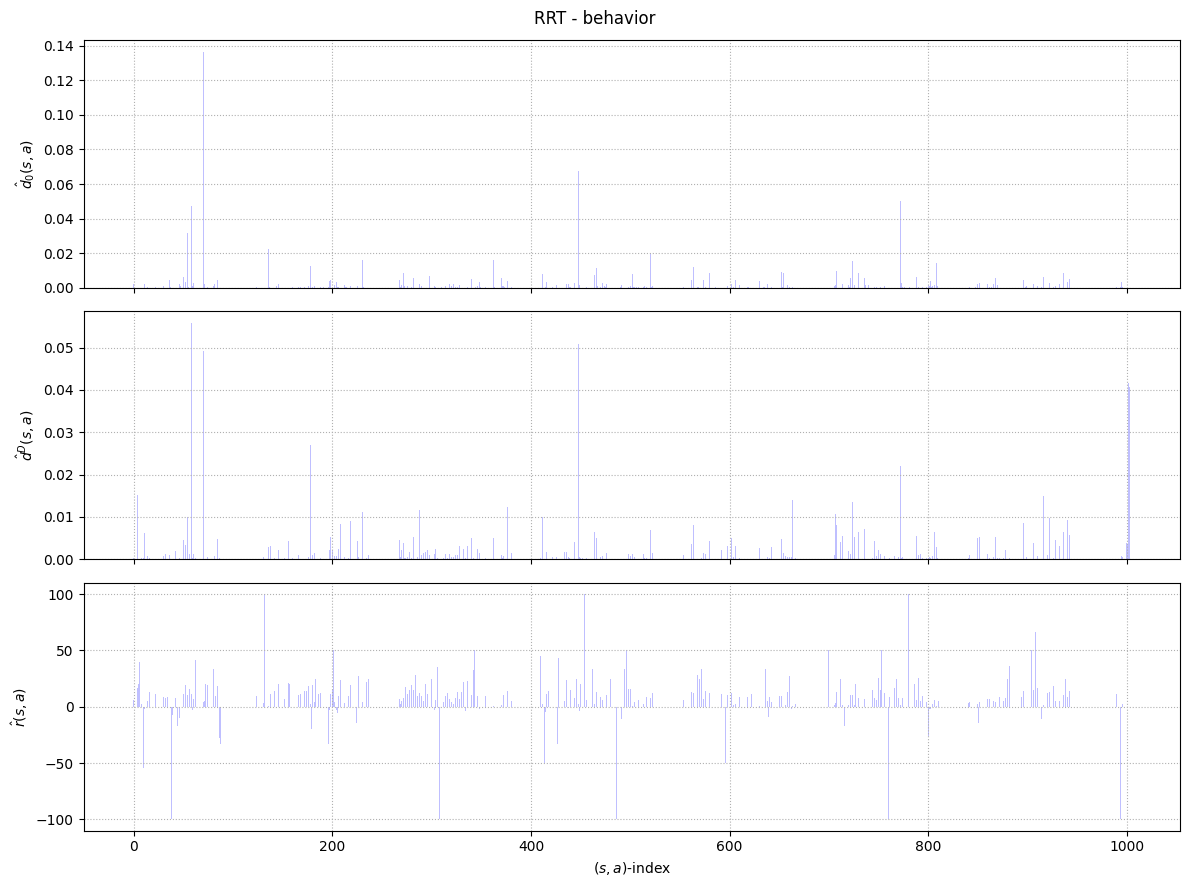

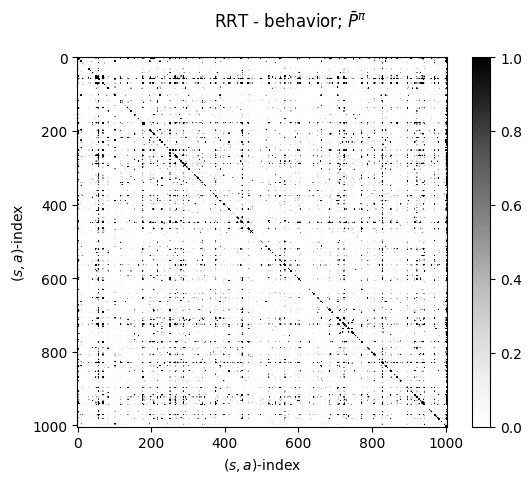

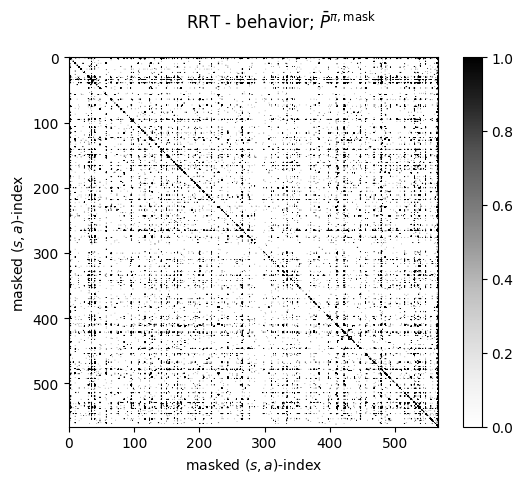

# ---------------------------------------------------------------- # 



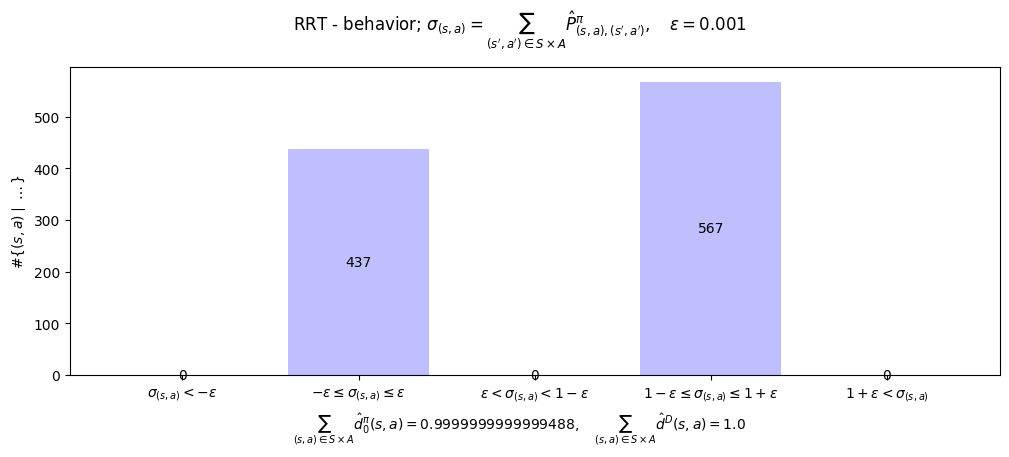

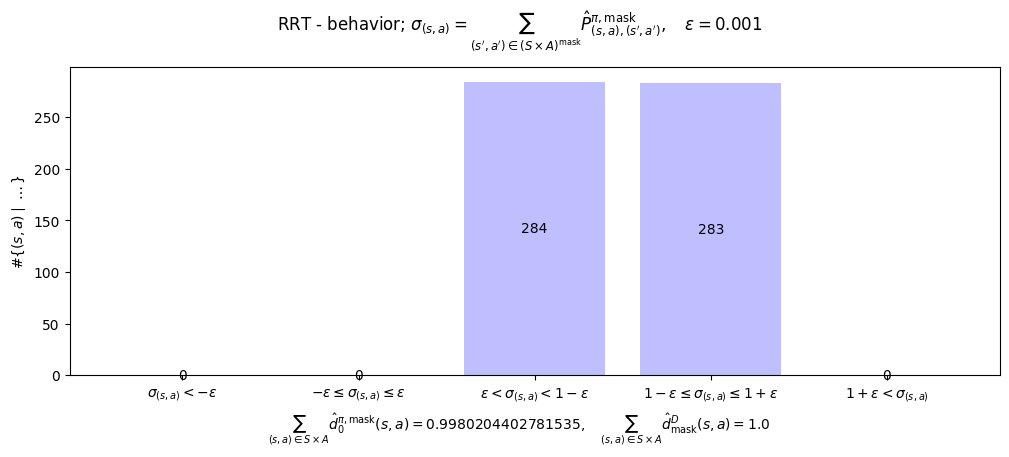

# ---------------------------------------------------------------- # 



In [34]:
test_auxiliary_estimates_RRT("behavior")

# (s, a) visited:
{'absolute': 567, 'relative': 0.5647410358565738}
# (s, a) not visited:
{'absolute': 437, 'relative': 0.4352589641434263}

#{i: dD_bar[i] == 0, P_bar[i, :] != 0} = 0
#{i: dD_bar[i] == 0, P_bar[:, i] != 0} = 4576
#{i: dD_bar[i] == 0, d0_bar[i] != 0} = 154

# ---------------------------------------------------------------- # 



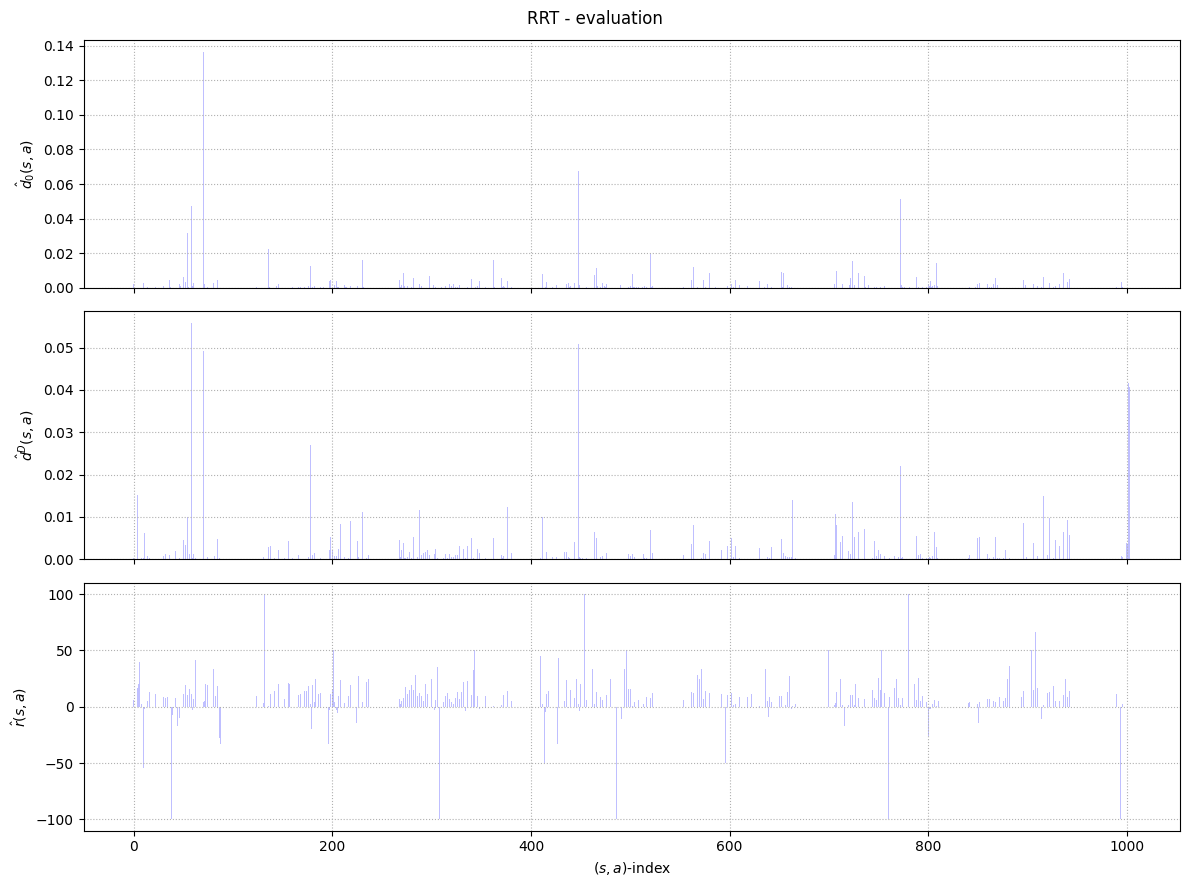

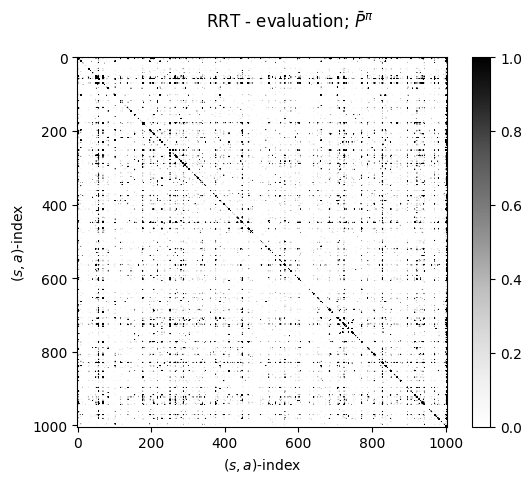

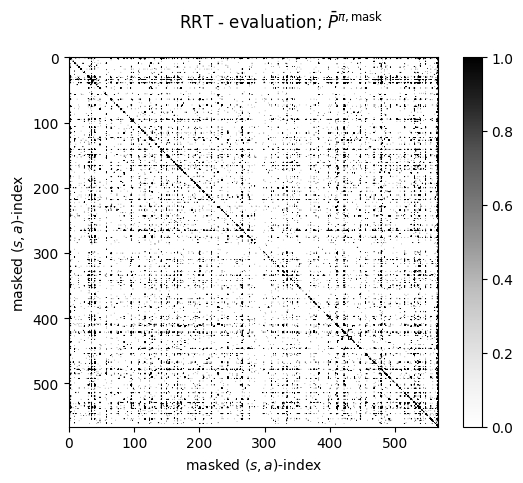

# ---------------------------------------------------------------- # 



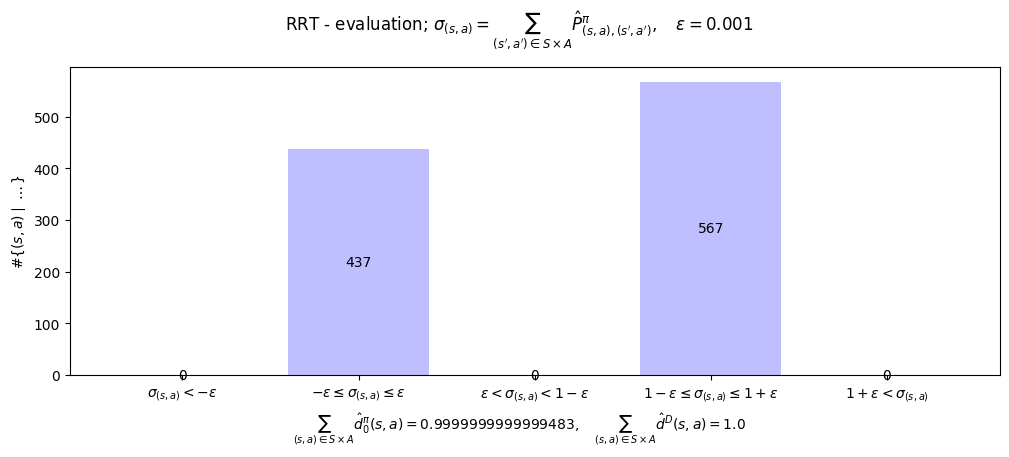

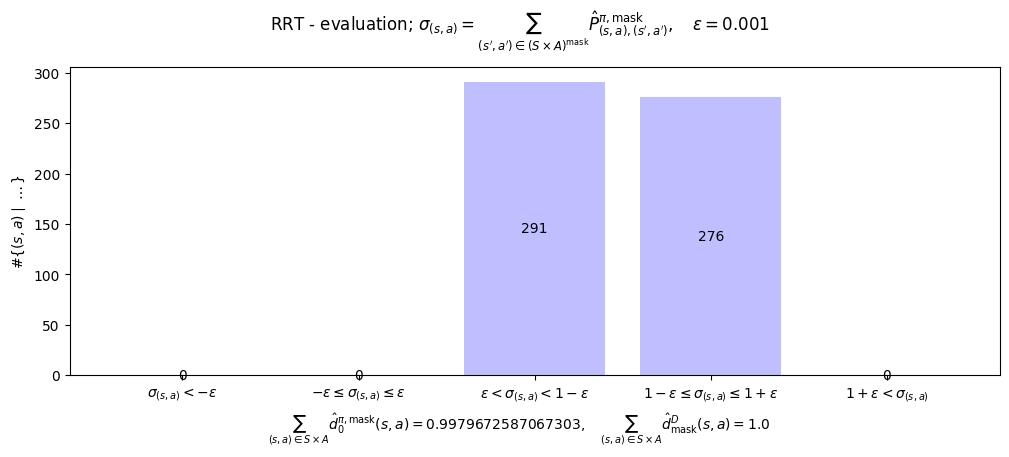

# ---------------------------------------------------------------- # 



In [35]:
test_auxiliary_estimates_RRT("evaluation")